# Dataset Exploration

In [ ]:
import glob
import re
import matplotlib.pyplot as plt
from datetime import datetime
import os
import nibabel as nib
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np
import tqdm as tqdm
from scipy.ndimage import zoom


In [ ]:
globs = glob.glob('**/*POST.nii.gz', recursive=True)
print(f"{len(globs)=}")

len(globs)=8996


### Histograms

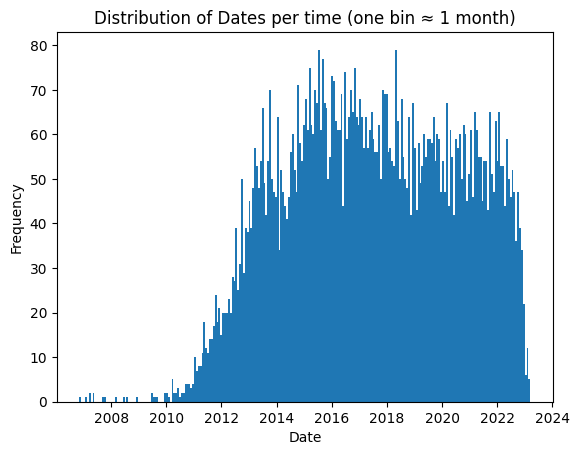

In [ ]:
date_pattern = re.compile(r'/(\d{4}-\d{2}-\d{2})/')
dates = [match.group(1) for path in globs if (match := date_pattern.search(path))]

# Convert date strings to datetime objects
date_objs = [datetime.strptime(date, "%Y-%m-%d") for date in dates]

# Plot the distribution of dates
plt.hist(date_objs, bins=20*12)
plt.xlabel('Date')
plt.ylabel('Frequency')
plt.title('Distribution of Dates per time (one bin ≈ 1 month)')
plt.show()

In [ ]:
num_entries = {os.path.dirname(glob).split("/")[2] : 0 for glob in globs}
for glob in globs:
    num_entries[os.path.dirname(glob).split("/")[2]] += 1
num_entries

{'Yale-Brain-Mets-Longitudinal': 8996}

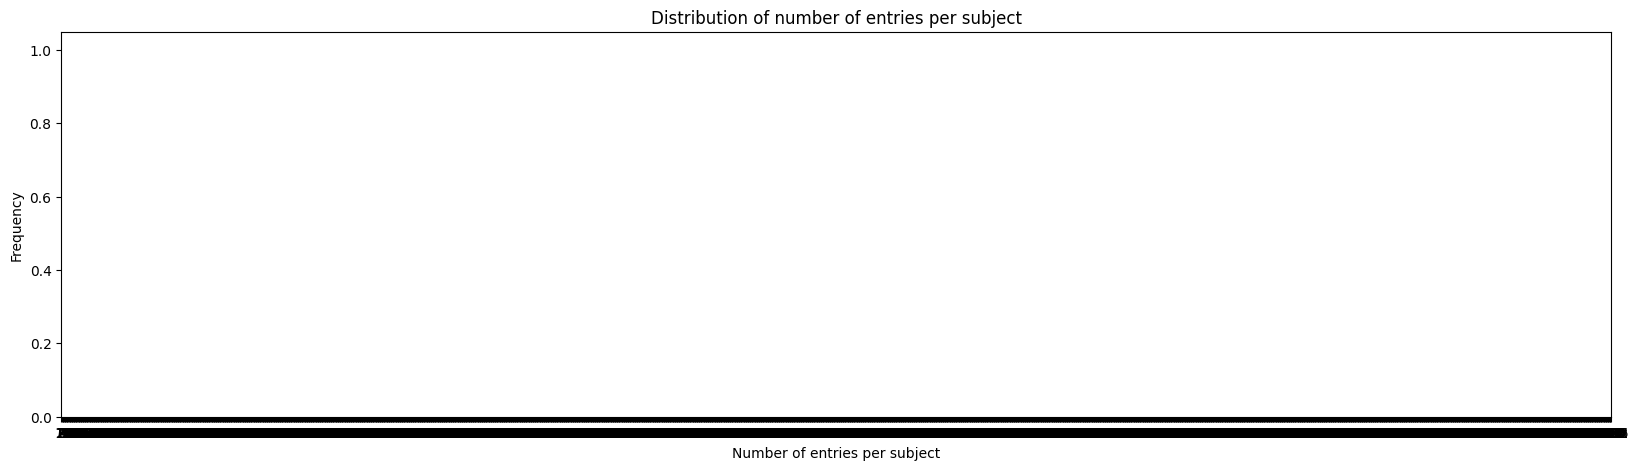

In [ ]:
plt.figure(figsize=(20, 5))
plt.hist(list(num_entries.values()), bins=max(list(num_entries.values())))
plt.xlabel('Number of entries per subject')
plt.ylabel('Frequency')
plt.xticks(range(0, max(list(num_entries.values())) + 1, 4))
plt.xlim(0, max(list(num_entries.values())) + 1)
plt.title('Distribution of number of entries per subject')
plt.show()

### Data Samples

In [ ]:
dimensions = []
for glob in globs:
    dimensions.append(nib.load(glob).shape)

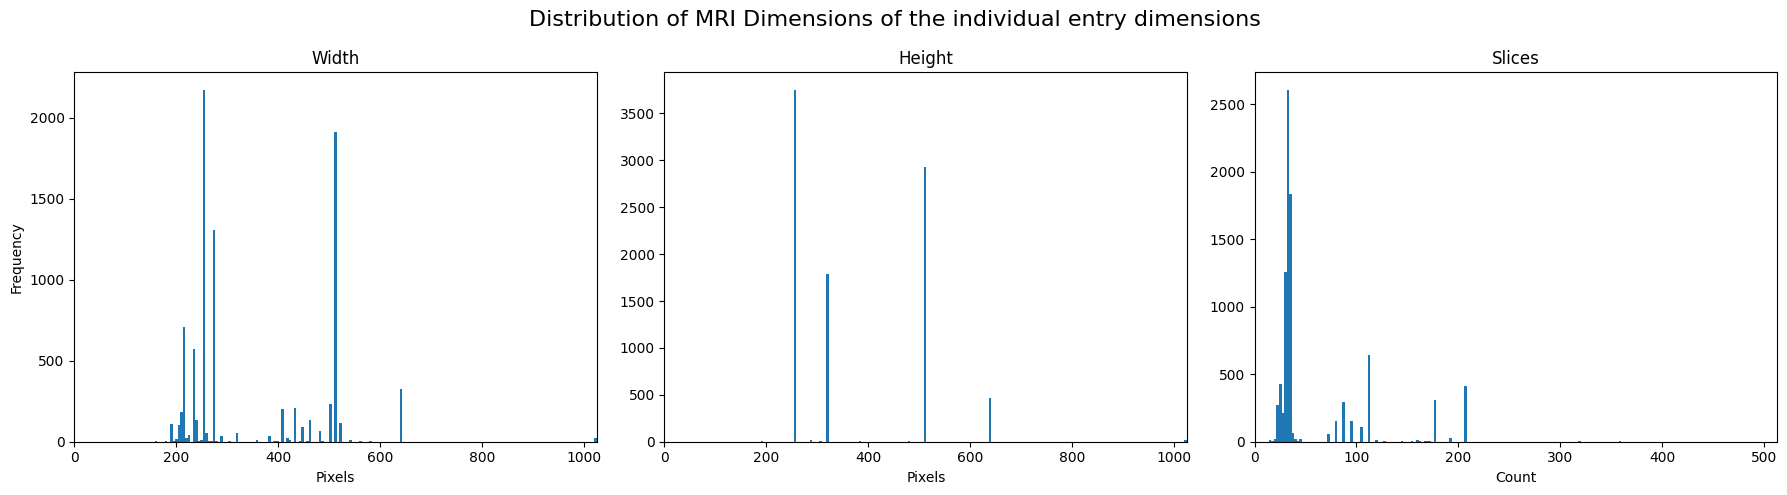

In [ ]:
widths, heights, slices = zip(*dimensions)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

fig.suptitle('Distribution of MRI Dimensions of the individual entry dimensions', fontsize=16)
axs[0].hist(widths, bins=200)
axs[0].set_title('Width')
axs[0].set_xlabel('Pixels')
axs[0].set_ylabel('Frequency')
axs[0].set_xlim(0, max(widths) + 1)

axs[1].hist(heights, bins=200)
axs[1].set_title('Height')
axs[1].set_xlabel('Pixels')
axs[1].set_xlim(0, max(heights) + 1)

axs[2].hist(slices, bins=200)
axs[2].set_title('Slices')
axs[2].set_xlabel('Count')
axs[2].set_xlim(0, max(slices) + 1)

plt.tight_layout()
plt.show()

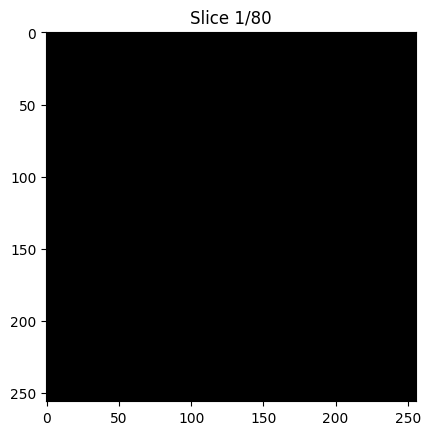

In [ ]:
entry = nib.load(globs[0])
entry = entry.get_fdata()

fig, ax = plt.subplots()
im = ax.imshow(entry[:, :, 0], cmap='gray', vmin=np.percentile(entry, 1), vmax=np.percentile(entry, 99))

def update(frame):
    im.set_data(entry[:, :, frame])
    ax.set_title(f'Slice {frame+1}/{entry.shape[2]}')
    return [im]

ani = FuncAnimation(fig, update, frames=entry.shape[2], interval=200)

HTML(ani.to_jshtml())


In [ ]:
means = []
for i, glob in enumerate(globs):
    means.append(np.mean(nib.load(glob).get_fdata(), axis=(0,1)))
    


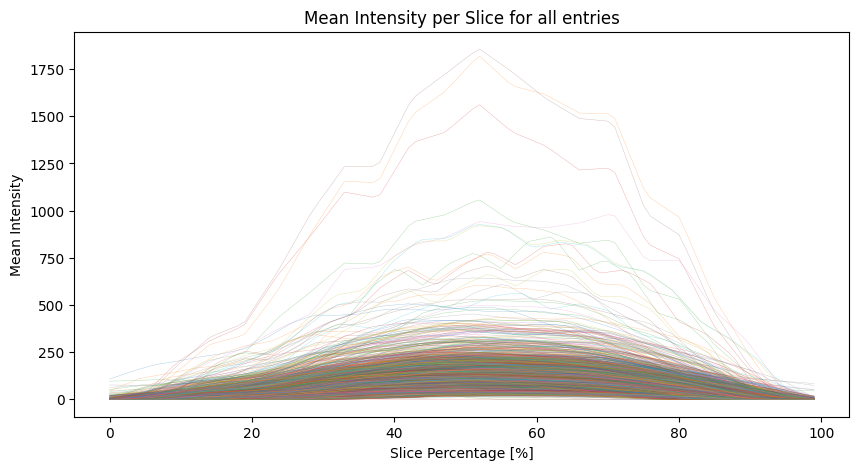

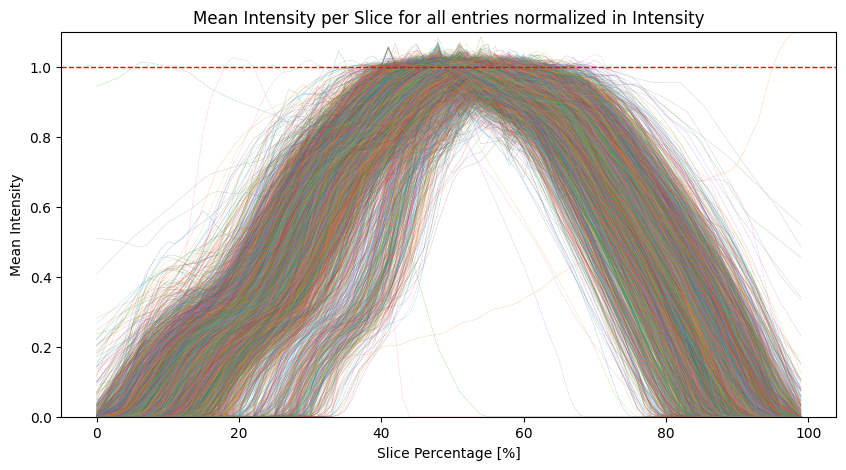

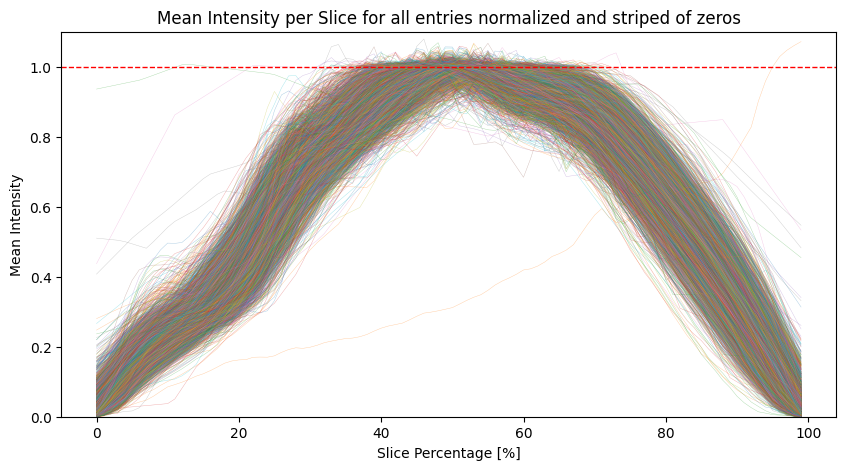

In [ ]:
plt.figure(figsize=(10, 5))

for mean in means:
    m = mean.copy()

    # Interpolate mean to 100 values
    x_old = np.linspace(0, 1, len(m))
    x_new = np.linspace(0, 1, 100)
    mean_interp = np.interp(x_new, x_old, m)
    plt.plot(mean_interp, alpha=0.4, linewidth=0.3)
    
plt.xlabel('Slice Percentage [%]')
plt.ylabel('Mean Intensity')
plt.title('Mean Intensity per Slice for all entries')
plt.show()

plt.figure(figsize=(10, 5))

for mean in means:
    m = mean.copy()
    
    # Interpolate mean to 100 values
    x_old = np.linspace(0, 1, len(m))
    x_new = np.linspace(0, 1, 100)
    mean_interp = np.interp(x_new, x_old, m)
    mean_interp = mean_interp / np.sort(mean_interp)[-5] 
    plt.plot(mean_interp, alpha=0.4, linewidth=0.3)
    
plt.xlabel('Slice Percentage [%]')
plt.ylabel('Mean Intensity')
plt.title('Mean Intensity per Slice for all entries normalized in Intensity')
plt.ylim(0, 1.1)
plt.axhline(1, color='red', linestyle='--', linewidth=1)
plt.show()

plt.figure(figsize=(10, 5))

for mean in means:
    m = mean.copy()
    
    sliced_mean = m[m != 0]

    # Interpolate mean to 100 values
    x_old = np.linspace(0, 1, len(sliced_mean))
    x_new = np.linspace(0, 1, 100)
    mean_interp = np.interp(x_new, x_old, sliced_mean)
    mean_interp = mean_interp / np.sort(mean_interp)[-5] 
    plt.plot(mean_interp, alpha=0.4, linewidth=0.3)
    
plt.xlabel('Slice Percentage [%]')
plt.ylabel('Mean Intensity')
plt.title('Mean Intensity per Slice for all entries normalized and striped of zeros')
plt.ylim(0, 1.1)
plt.axhline(1, color='red', linestyle='--', linewidth=1)
plt.show()


## Get labels / segmentation

The dataset itself does not have labels nor seqmentations. One way to get them is to use nnUnetv2 which would predict the labels. We visualize the predictions:

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

# Load original MRI
mri = nib.load("original_YG_01M98EKKAR50/2016-11-27/YG_01M98EKKAR50_2016-11-27_10-38-46_POST.nii.gz").get_fdata()

# Load segmentation prediction
seg = nib.load("YG_01M98EKKAR50/2016-11-27/0.nii.gz").get_fdata()

# Ensure segmentation is binary (optional, depending on your data)
seg_binary = seg > 0  # Adjust threshold if necessary

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Show first slice of MRI
im_mri_left = axes[0].imshow(mri[:, :, 0], cmap='gray', vmin=mri.min(), vmax=mri.max())
axes[0].set_title('MRI with Segmentation Overlay in Dark Red')

# Overlay first slice of segmentation on the left plot
im_seg_left = axes[0].imshow(seg_binary[:, :, 0], cmap='Reds', alpha=0.5, vmin=0, vmax=1)

# Show first slice of MRI on the right plot
im_mri_right = axes[1].imshow(mri[:, :, 0], cmap='gray', vmin=mri.min(), vmax=mri.max())
axes[1].set_title('MRI')

def update(frame):
    im_mri_left.set_data(mri[:, :, frame])
    im_seg_left.set_data(seg_binary[:, :, frame])

    im_mri_right.set_data(mri[:, :, frame])
ani = FuncAnimation(fig, update, frames=mri.shape[2], interval=200)

HTML(ani.to_jshtml())
